## بارگذاری مدل های ذخیره شده

In [32]:
from tensorflow.keras.models import load_model


mobile_model = load_model(
    "MobileNetV2.keras"
)

print("MobileNetV2 loaded")

MobileNetV2 loaded


## بررسی وجود فایل ها

In [44]:
import os

print("MobileNetV2:", os.path.exists("MobileNetV2.keras"))
print("EfficientNetB3:", os.path.exists("EfficientNetB3.keras"))
print("Dataset:", os.path.exists("Dataset"))

MobileNetV2: True
EfficientNetB3: True
Dataset: True


## ساخت خط لوله داده بدون نرمال سازی

In [3]:
import tensorflow as tf
import os

# تنظیمات
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DATASET_DIR = "Dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VALID_DIR = os.path.join(DATASET_DIR, "valid")

# ساخت دیتاست آموزش
train_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

# ساخت دیتاست اعتبارسنجی
valid_raw = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Class names:", train_raw.class_names)
print("Train batches:", tf.data.experimental.cardinality(train_raw).numpy())
print("Validation batches:", tf.data.experimental.cardinality(valid_raw).numpy())

Found 10682 files belonging to 2 classes.
Found 3562 files belonging to 2 classes.
Class names: ['Melanoma', 'NotMelanoma']
Train batches: 334
Validation batches: 112


## بررسی مقادیر پیکسل های تصاویر

In [4]:
for images, labels in train_raw.take(1):
    print("Image shape:", images.shape)
    print("Image dtype:", images.dtype)
    print("Minimum pixel:", tf.reduce_min(images).numpy())
    print("Maximum pixel:", tf.reduce_max(images).numpy())
    print("Labels:", labels[:10].numpy().flatten())

Image shape: (32, 224, 224, 3)
Image dtype: <dtype: 'float32'>
Minimum pixel: 0.0
Maximum pixel: 255.0
Labels: [0. 1. 1. 1. 0. 1. 0. 0. 0. 0.]


## بهینه سازی خط لوله

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_raw = train_raw.prefetch(AUTOTUNE)
valid_raw = valid_raw.prefetch(AUTOTUNE)

print("Dataset pipeline is ready.")

Dataset pipeline is ready.


## ساخت مدل EfficientNetB3

In [6]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models
import tensorflow as tf

def build_efficientnet_model():

    base_model = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # در مرحله اول فقط لایه‌های جدید را آموزش می‌دهیم
    base_model.trainable = False

    model = models.Sequential([
        
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.3),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


efficient_model = build_efficientnet_model()

efficient_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)          │ (None, 7, 7, 1536)          │      10,783,535 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1536)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         196,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,980,400 (41.89 MB)

 Trainable params: 196,865 (769.00 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

## آموزش EfficientNetB3__مرحله یادگیری انتقالی

In [7]:
EPOCHS_EFFICIENT_TRANSFER = 5

history_efficient_transfer = efficient_model.fit(
    train_raw,
    validation_data=valid_raw,
    epochs=EPOCHS_EFFICIENT_TRANSFER
)

Epoch 1/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 531s 2s/step - accuracy: 0.8624 - loss: 0.3415 - val_accuracy: 0.9200 - val_loss: 0.2168
Epoch 2/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 500s 1s/step - accuracy: 0.9062 - loss: 0.2450 - val_accuracy: 0.9231 - val_loss: 0.1954
Epoch 3/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.9136 - loss: 0.2328 - val_accuracy: 0.9301 - val_loss: 0.1821
Epoch 4/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.9183 - loss: 0.2160 - val_accuracy: 0.9377 - val_loss: 0.1762
Epoch 5/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.9221 - loss: 0.2069 - val_accuracy: 0.9371 - val_loss: 0.1677


## باز کردن بدنه برای تنظیم دقیق (50 لایه آخر)

In [8]:
 # فعال کردن Fine-Tuning برای EfficientNetB3

base_model = efficient_model.layers[0]

base_model.trainable = True

# بیشتر لایه‌ها همچنان فریز می‌مانند
# فقط 50 لایه آخر آموزش داده می‌شوند
for layer in base_model.layers[:-50]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))

trainable_count = sum(
    1 for layer in base_model.layers
    if layer.trainable
)

print("Trainable layers:", trainable_count)

Total layers: 385
Trainable layers: 50


## بررسی اینکه کدام لایه ها آموزش پذیرند

In [9]:
# بررسی اینکه کدام لایه‌ها قابل آموزش هستند

for layer in base_model.layers[-60:]:
    print(
        layer.name,
        "->",
        "Trainable" if layer.trainable else "Frozen"
    )

block6e_expand_bn -> Frozen
block6e_expand_activation -> Frozen
block6e_dwconv -> Frozen
block6e_bn -> Frozen
block6e_activation -> Frozen
block6e_se_squeeze -> Frozen
block6e_se_reshape -> Frozen
block6e_se_reduce -> Frozen
block6e_se_expand -> Frozen
block6e_se_excite -> Frozen
block6e_project_conv -> Trainable
block6e_project_bn -> Trainable
block6e_drop -> Trainable
block6e_add -> Trainable
block6f_expand_conv -> Trainable
block6f_expand_bn -> Trainable
block6f_expand_activation -> Trainable
block6f_dwconv -> Trainable
block6f_bn -> Trainable
block6f_activation -> Trainable
block6f_se_squeeze -> Trainable
block6f_se_reshape -> Trainable
block6f_se_reduce -> Trainable
block6f_se_expand -> Trainable
block6f_se_excite -> Trainable
block6f_project_conv -> Trainable
block6f_project_bn -> Trainable
block6f_drop -> Trainable
block6f_add -> Trainable
block7a_expand_conv -> Trainable
block7a_expand_bn -> Trainable
block7a_expand_activation -> Trainable
block7a_dwconv -> Trainable
block7a_bn

## کامپایل مجدد برای تنظیم دقیق

In [10]:
# Compile مجدد برای Fine-Tuning
# Learning Rate کوچک برای جلوگیری از خراب شدن وزن‌های ImageNet

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB3 recompiled for fine-tuning.")

EfficientNetB3 recompiled for fine-tuning.


## تنظیم دقیق EfficientNetB3 ( 2 اپوک)

In [11]:
history_efficient_ft = efficient_model.fit(
    train_raw,
    validation_data=valid_raw,
    epochs=2
)

Epoch 1/2
334/334 ━━━━━━━━━━━━━━━━━━━━ 676s 2s/step - accuracy: 0.8804 - loss: 0.3140 - val_accuracy: 0.9312 - val_loss: 0.1966
Epoch 2/2
334/334 ━━━━━━━━━━━━━━━━━━━━ 639s 2s/step - accuracy: 0.9180 - loss: 0.2193 - val_accuracy: 0.9396 - val_loss: 0.1683


## ذخیره مدل نهایی EfficientNetB3

In [40]:
efficient_model.save("EfficientNetB3.keras")

print("EfficientNetB3 final model saved successfully.")

EfficientNetB3 final model saved successfully.


## تأیید فایل ذخیره شده و حجم آن

In [42]:
import os

print(
    "EfficientNetB3.keras:",
    os.path.exists("EfficientNetB3.keras")
)

if os.path.exists("EfficientNetB3.keras"):
    print(
        "File size:",
        round(os.path.getsize("EfficientNetB3_final.keras") / (1024**2), 2),
        "MB"
    )

EfficientNetB3.keras: True
File size: 83.23 MB


## ساخت مجدد دیتاست اعتبارسنجی و نگه داشتن نام کلاس ها

In [4]:
import tensorflow as tf
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALID_DIR = os.path.join("Dataset", "valid")

# ابتدا Dataset اصلی را می‌سازیم
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

# کلاس‌ها را قبل از prefetch ذخیره می‌کنیم
class_names = valid_dataset.class_names

# سپس prefetch
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)

print("Validation dataset ready.")
print("Classes:", class_names)

Found 3562 files belonging to 2 classes.
Validation dataset ready.
Classes: ['Melanoma', 'NotMelanoma']


## ارزیابی MobileNetV2 ذخیره شده 

In [5]:
print("Evaluating MobileNetV2...")

mobile_loss, mobile_accuracy = mobile_model.evaluate(
    valid_dataset,
    verbose=1
)

print("\nMobileNetV2 Results")
print("-------------------")
print(f"Loss     : {mobile_loss:.4f}")
print(f"Accuracy : {mobile_accuracy:.4f}")
print(f"Accuracy : {mobile_accuracy * 100:.2f}%")

Evaluating MobileNetV2...
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 443ms/step - accuracy: 0.9293 - loss: 0.2082

MobileNetV2 Results
-------------------
Loss     : 0.2082
Accuracy : 0.9293
Accuracy : 92.93%


## ارزیابی EfficientNetB3

In [17]:
print("Evaluating EfficientNetB3...")

efficient_loss, efficient_accuracy = efficient_model.evaluate(
    valid_dataset,
    verbose=1
)

print("\nEfficientNetB3 Results")
print("----------------------")
print(f"Loss     : {efficient_loss:.4f}")
print(f"Accuracy : {efficient_accuracy:.4f}")
print(f"Accuracy : {efficient_accuracy * 100:.2f}%")

Evaluating EfficientNetB3...
112/112 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9396 - loss: 0.1683

EfficientNetB3 Results
----------------------
Loss     : 0.1683
Accuracy : 0.9396
Accuracy : 93.96%


## گزارش طبقه بندی برای هر دو مدل (Classification Report)

In [6]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# --------------------------------
# گرفتن برچسب‌های واقعی
# --------------------------------

y_true = np.concatenate([
    y.numpy().astype(int).flatten()
    for _, y in valid_dataset
])

print("Number of true labels:", len(y_true))
print("Class names:", class_names)


# --------------------------------
# پیش‌بینی MobileNetV2
# --------------------------------

print("\nPredicting with MobileNetV2...")

mobile_predictions = mobile_model.predict(
    valid_dataset,
    verbose=1
)

mobile_y_pred = (
    mobile_predictions.flatten() >= 0.5
).astype(int)


# --------------------------------
# پیش‌بینی EfficientNetB3
# --------------------------------

print("\nPredicting with EfficientNetB3...")

efficient_predictions = efficient_model.predict(
    valid_dataset,
    verbose=1
)

efficient_y_pred = (
    efficient_predictions.flatten() >= 0.5
).astype(int)


# --------------------------------
# Classification Report - MobileNetV2
# --------------------------------

print("\n" + "="*60)
print("MobileNetV2 - Classification Report")
print("="*60)

print(
    classification_report(
        y_true,
        mobile_y_pred,
        target_names=class_names,
        digits=4
    )
)


# --------------------------------
# Classification Report - EfficientNetB3
# --------------------------------

print("\n" + "="*60)
print("EfficientNetB3 - Classification Report")
print("="*60)

print(
    classification_report(
        y_true,
        efficient_y_pred,
        target_names=class_names,
        digits=4
    )
)

Number of true labels: 3562
Class names: ['Melanoma', 'NotMelanoma']

Predicting with MobileNetV2...
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 468ms/step

Predicting with EfficientNetB3...
112/112 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step

MobileNetV2 - Classification Report
              precision    recall  f1-score   support

    Melanoma     0.9722    0.8838    0.9259      1781
 NotMelanoma     0.8935    0.9747    0.9323      1781

    accuracy                         0.9293      3562
   macro avg     0.9328    0.9293    0.9291      3562
weighted avg     0.9328    0.9293    0.9291      3562


EfficientNetB3 - Classification Report
              precision    recall  f1-score   support

    Melanoma     0.9734    0.9040    0.9374      1781
 NotMelanoma     0.9104    0.9753    0.9417      1781

    accuracy                         0.9396      3562
   macro avg     0.9419    0.9396    0.9396      3562
weighted avg     0.9419    0.9396    0.9396      3562



## ماتریس درهم ریختگی برای هر دو مدل

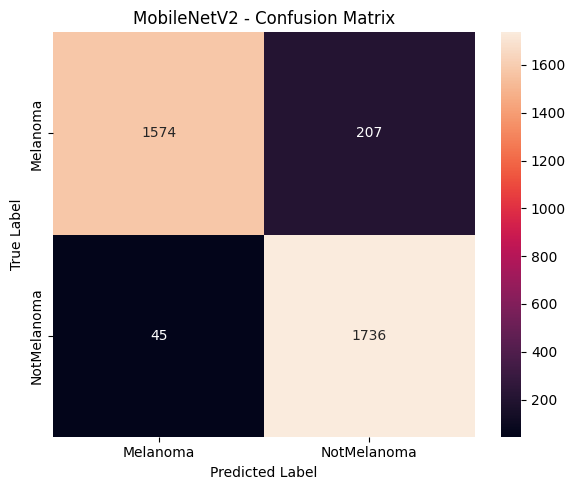

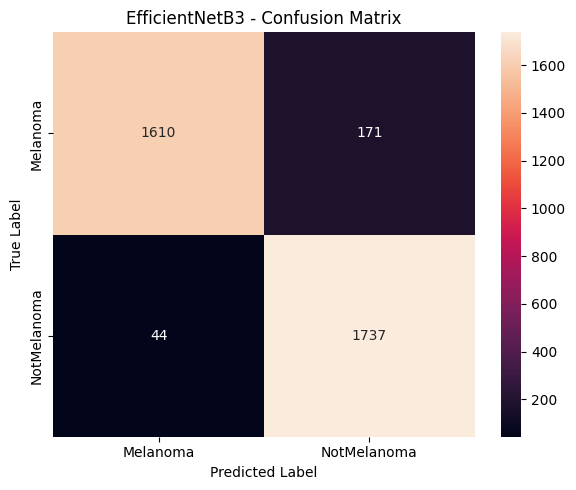

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# Confusion Matrix - MobileNetV2
# ==========================================

cm_mobile = confusion_matrix(
    y_true,
    mobile_y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# ==========================================
# Confusion Matrix - EfficientNetB3
# ==========================================

cm_efficient = confusion_matrix(
    y_true,
    efficient_y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_efficient,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("EfficientNetB3 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## کالبدشکافی پیش بینی های MobileNetV2 (سلول تشخیص)

In [45]:
print("MobileNetV2 prediction statistics")
print("----------------------------------")

print("Minimum:", mobile_predictions.min())
print("Maximum:", mobile_predictions.max())
print("Mean:", mobile_predictions.mean())

print("\nFirst 20 predictions:")
print(mobile_predictions[:20].flatten())

MobileNetV2 prediction statistics
----------------------------------
Minimum: 0.00023595915
Maximum: 0.99743336
Mean: 0.5065061

First 20 predictions:
[0.00639903 0.00271667 0.00741174 0.0058644  0.00438749 0.11575507
 0.00345904 0.01130721 0.00659891 0.00093033 0.00514387 0.00146333
 0.0031454  0.00393824 0.04189578 0.00430068 0.00214151 0.06310239
 0.00411926 0.00695929]


## ساخت MobileNetV2 جدید 

### نسخه اصلاح شده

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# ----------------------------------------
# ساخت MobileNetV2 جدید
# ----------------------------------------

def build_mobilenet_model():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # فعلاً Backbone کاملاً فریز است
    base_model.trainable = False

    model = models.Sequential([
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.3),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


mobile_model_new = build_mobilenet_model()

mobile_model_new.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## چاپ اطلاعات مدل جدید

In [48]:
print("MobileNetV2 model created successfully.")
print("Total parameters:", mobile_model_new.count_params())
print("Output shape:", mobile_model_new.output_shape)

MobileNetV2 model created successfully.
Total parameters: 2422081
Output shape: (None, 1)


## آموزش MobileNetV2 جدید

### یک اپوک اول

In [23]:
history_mobile_test = mobile_model_new.fit(
    train_raw,
    validation_data=valid_raw,
    epochs=1
)

334/334 ━━━━━━━━━━━━━━━━━━━━ 206s 600ms/step - accuracy: 0.8269 - loss: 0.4222 - val_accuracy: 0.8947 - val_loss: 0.2783


## ادامه آموزش MobileNetV2 (4 اپوک)

In [24]:
history_mobile = mobile_model_new.fit(
    train_raw,
    validation_data=valid_raw,
    epochs=4
)

Epoch 1/4
334/334 ━━━━━━━━━━━━━━━━━━━━ 196s 587ms/step - accuracy: 0.8902 - loss: 0.3053 - val_accuracy: 0.9155 - val_loss: 0.2401
Epoch 2/4
334/334 ━━━━━━━━━━━━━━━━━━━━ 201s 602ms/step - accuracy: 0.9018 - loss: 0.2747 - val_accuracy: 0.9211 - val_loss: 0.2237
Epoch 3/4
334/334 ━━━━━━━━━━━━━━━━━━━━ 197s 590ms/step - accuracy: 0.9069 - loss: 0.2565 - val_accuracy: 0.9214 - val_loss: 0.2169
Epoch 4/4
334/334 ━━━━━━━━━━━━━━━━━━━━ 198s 592ms/step - accuracy: 0.9138 - loss: 0.2431 - val_accuracy: 0.9293 - val_loss: 0.2082


## ذخیره MobileNetV2_final

In [36]:
mobile_model.save("MobileNetV2_final.keras")

### نسخه قبل از تنظیم دقیق

## تأیید فایل و حجم آن

In [26]:
import os

print(
    os.path.exists("MobileNetV2_final.keras")
)

print(
    round(
        os.path.getsize("MobileNetV2_final.keras")/(1024**2),
        2
    ),
    "MB"
)

True
11.06 MB


## باز کردن بدنه MobileNetV2 برای تنظیم دقیق

### 30 لایه آخر

In [27]:
# Fine-Tuning MobileNetV2

base_mobile = mobile_model_new.layers[0]

base_mobile.trainable = True

# همه لایه‌ها به جز 30 لایه آخر فریز
for layer in base_mobile.layers[:-30]:
    layer.trainable = False


print("Total layers:", len(base_mobile.layers))

trainable_layers = sum(
    1 for layer in base_mobile.layers
    if layer.trainable
)

print("Trainable layers:", trainable_layers)

Total layers: 154
Trainable layers: 30


## بررسی لایه های آموزش پذیر

In [28]:
for layer in base_mobile.layers[-40:]:
    print(
        layer.name,
        "->",
        "Trainable" if layer.trainable else "Frozen"
    )

block_12_project_BN -> Frozen
block_12_add -> Frozen
block_13_expand -> Frozen
block_13_expand_BN -> Frozen
block_13_expand_relu -> Frozen
block_13_pad -> Frozen
block_13_depthwise -> Frozen
block_13_depthwise_BN -> Frozen
block_13_depthwise_relu -> Frozen
block_13_project -> Frozen
block_13_project_BN -> Trainable
block_14_expand -> Trainable
block_14_expand_BN -> Trainable
block_14_expand_relu -> Trainable
block_14_depthwise -> Trainable
block_14_depthwise_BN -> Trainable
block_14_depthwise_relu -> Trainable
block_14_project -> Trainable
block_14_project_BN -> Trainable
block_14_add -> Trainable
block_15_expand -> Trainable
block_15_expand_BN -> Trainable
block_15_expand_relu -> Trainable
block_15_depthwise -> Trainable
block_15_depthwise_BN -> Trainable
block_15_depthwise_relu -> Trainable
block_15_project -> Trainable
block_15_project_BN -> Trainable
block_15_add -> Trainable
block_16_expand -> Trainable
block_16_expand_BN -> Trainable
block_16_expand_relu -> Trainable
block_16_dep

## کامپایل مجدد با نرخ یادگیری کوچک

In [29]:
mobile_model_new.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 recompiled for fine-tuning.")

MobileNetV2 recompiled for fine-tuning.


## تنظیم دقیق MobileNetV2__نتیجه منفی مهم

In [30]:
history_mobile_ft = mobile_model_new.fit(
    train_raw,
    validation_data=valid_raw,
    epochs=3
)

Epoch 1/3
334/334 ━━━━━━━━━━━━━━━━━━━━ 262s 745ms/step - accuracy: 0.8955 - loss: 0.2852 - val_accuracy: 0.8762 - val_loss: 0.3101
Epoch 2/3
334/334 ━━━━━━━━━━━━━━━━━━━━ 249s 746ms/step - accuracy: 0.9229 - loss: 0.2056 - val_accuracy: 0.8515 - val_loss: 0.3516
Epoch 3/3
334/334 ━━━━━━━━━━━━━━━━━━━━ 244s 732ms/step - accuracy: 0.9295 - loss: 0.1854 - val_accuracy: 0.8897 - val_loss: 0.2823


## بازگرداندن بهترین نسخه MobileNetV2

In [37]:
from tensorflow.keras.models import load_model

mobile_model_final = load_model(
    "MobileNetV2_final.keras"
)

print("MobileNetV2 best model loaded.")

MobileNetV2 best model loaded.


## ارزیابی مدل نهایی MobileNetV2

In [32]:
mobile_loss, mobile_accuracy = mobile_model_final.evaluate(
    valid_dataset,
    verbose=1
)

print("MobileNetV2 Final Accuracy:")
print(mobile_accuracy)

112/112 ━━━━━━━━━━━━━━━━━━━━ 51s 424ms/step - accuracy: 0.9293 - loss: 0.2082
MobileNetV2 Final Accuracy:
0.9292532205581665


## فهرست لایه های کانولوشنی انتهایی EfficientNetB3

In [33]:
# نمایش لایه های کانولوشنی انتهایی EfficientNetB3

efficient_base = efficient_model.layers[0]

for layer in efficient_base.layers[-50:]:
    if "conv" in layer.name.lower():
        print(layer.name)

block6e_project_conv
block6f_expand_conv
block6f_dwconv
block6f_project_conv
block7a_expand_conv
block7a_dwconv
block7a_project_conv
block7b_expand_conv
block7b_dwconv
block7b_project_conv
top_conv


## تعریف تابع Grad-CAM

In [34]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    base_model = model.layers[0]

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]


    grads = tape.gradient(
        loss,
        conv_outputs
    )


    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )


    conv_outputs = conv_outputs[0]


    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)


    heatmap = tf.maximum(
        heatmap,
        0
    ) / tf.math.reduce_max(heatmap)


    return heatmap.numpy()


print("Grad-CAM function ready")

Grad-CAM function ready


## انتخاب لایه Grad-CAM

## آزمون چهار لایه کاندید

In [48]:
test_layers = [
    "block6f_project_conv",
    "block7a_project_conv",
    "block7b_expand_conv",
    "top_conv"
]


for layer_name in test_layers:

    heatmap = make_gradcam_heatmap_efficient(
        img_array,
        efficient_model,
        base_model,
        layer_name
    )

    print(
        layer_name,
        "min:",
        heatmap.min(),
        "max:",
        heatmap.max(),
        "mean:",
        heatmap.mean()
    )

block6f_project_conv min: 0.0 max: 0.9999999 mean: 0.24260864
block7a_project_conv min: 0.0 max: 0.99999994 mean: 0.1698
block7b_expand_conv min: 0.0 max: 0.99999994 mean: 0.097219914
top_conv min: 0.0 max: 0.99999994 mean: 0.191282


##  تثبیت لایه انتخابی

In [49]:
last_conv_layer_name = "block6f_project_conv"

## تولید نقشه با لایه نهایی

In [50]:
heatmap = make_gradcam_heatmap_efficient(
    img_array,
    efficient_model,
    base_model,
    last_conv_layer_name
)

print("Heatmap:")
print("min:", heatmap.min())
print("max:", heatmap.max())
print("mean:", heatmap.mean())

Heatmap:
min: 0.0
max: 0.9999999
mean: 0.24260864


## نمایش نهایی و درست Grad-CAM

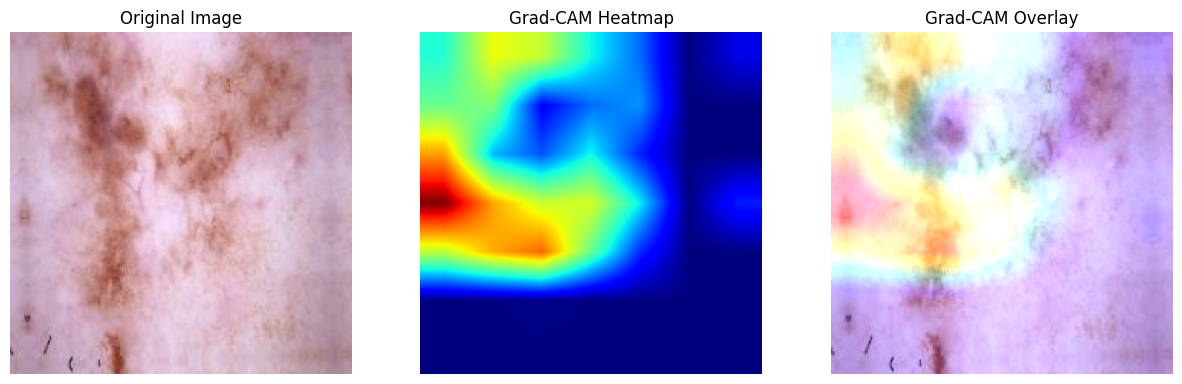

In [51]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def display_gradcam(img, heatmap, alpha=0.4):

    # تبدیل heatmap به 0-255
    heatmap_uint8 = np.uint8(255 * heatmap)

    # بزرگ کردن heatmap به اندازه تصویر اصلی
    heatmap_resized = cv2.resize(
        heatmap_uint8,
        (img.shape[1], img.shape[0])
    )

    # اعمال رنگ
    heatmap_color = cv2.applyColorMap(
        heatmap_resized,
        cv2.COLORMAP_JET
    )

    # تبدیل BGR به RGB
    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # ترکیب با تصویر اصلی
    overlay = (
        heatmap_color * alpha +
        img
    )

    overlay = np.uint8(
        np.clip(overlay, 0, 255)
    )


    plt.figure(figsize=(15,5))


    plt.subplot(1,3,1)
    plt.imshow(img.astype("uint8"))
    plt.title("Original Image")
    plt.axis("off")


    plt.subplot(1,3,2)
    plt.imshow(
        heatmap_resized,
        cmap="jet"
    )
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")


    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")


    plt.show()


display_gradcam(
    test_image.numpy(),
    heatmap
)

## ذخیره مدل ها در پوشه saved_models

In [52]:
import os

os.makedirs("saved_models", exist_ok=True)

# ذخیره EfficientNetB3
efficient_model.save(
    "saved_models/EfficientNetB3_final.keras"
)

# ذخیره MobileNetV2
mobile_model_new.save(
    "saved_models/MobileNetV2_final.keras"
)

print("Models saved successfully.")

Models saved successfully.


## ساخت فایل پیکربندی پروژه (project_config.json)

In [49]:
import json


project_config = {
    "image_size": [224,224],
    "class_names": class_names,
    "efficientnet_gradcam_layer": "block6f_project_conv",
    "efficientnet_accuracy": 0.9396,
    "mobilenet_accuracy": 0.9293
}


with open(
    "saved_models/project_config.json",
    "w"
) as f:

    json.dump(
        project_config,
        f,
        indent=4
    )


print("Config saved.")

Config saved.


## فهرست کردن فایل های پوشه saved_models

### اجرای اول

In [52]:
import os

for file in os.listdir("saved_models"):
    print(file)

EfficientNetB3_final.keras
MobileNetV2_final.keras
model_comparison.csv
project_config.json


## ساخت پوشه ذخیره نتایج Grad-CAM

In [62]:
import os

RESULT_DIR = "GradCAM_Results"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("Results folder ready:", RESULT_DIR)

Results folder ready: GradCAM_Results


## چاپ مسیر جاری پروژه

In [77]:
import os

print(os.getcwd())

D:\Melanoma_skin


## ذخیره فایل GradCAM_final_results.csv

In [61]:
gradcam_df.to_csv(
    "GradCAM_final_results.csv",
    index=False
)

print("GradCAM results saved.")

GradCAM results saved.


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def calculate_metrics(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Specificity": specificity
    }


mobile_metrics = calculate_metrics(
    y_true,
    mobile_y_pred
)

efficient_metrics = calculate_metrics(
    y_true,
    efficient_y_pred
)


print("MobileNetV2")
print("----------------")
for key, value in mobile_metrics.items():
    print(f"{key}: {value:.4f}")


print("\nEfficientNetB3")
print("----------------")
for key, value in efficient_metrics.items():
    print(f"{key}: {value:.4f}")

MobileNetV2
----------------
Accuracy: 0.9293
Precision: 0.8935
Recall: 0.9747
F1-Score: 0.9323
Specificity: 0.8838

EfficientNetB3
----------------
Accuracy: 0.9396
Precision: 0.9104
Recall: 0.9753
F1-Score: 0.9417
Specificity: 0.9040


## مقایسه کامل دو مدل در جدول

In [64]:
import pandas as pd

comparison_df = pd.DataFrame(
    [mobile_metrics, efficient_metrics],
    index=["MobileNetV2", "EfficientNetB3"]
)

comparison_df

,Accuracy,Precision,Recall,F1-Score,Specificity
MobileNetV2,0.929253,0.893464,0.974733,0.932331,0.883773
EfficientNetB3,0.939641,0.910377,0.975295,0.941719,0.903987


## ذخیره مدل ها

In [65]:
comparison_df.to_csv(
    "saved_models/model_comparison.csv"
)

print("Model comparison saved.")

Model comparison saved.
